# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [6]:
df_clean = pd.read_csv("cleaned_aviation_data.csv")
print("Cleaned data loaded. Shape:", df_clean.shape)
df_clean.head()

Cleaned data loaded. Shape: (20764, 26)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,...,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Total.Passengers,Is_Destroyed,Make_Model
0,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,Non-Fatal,Substantial,Airplane,CF-TLU,...,Unknown,0.0,0.0,1.0,44.0,VMC,Climb,45.0,0,MCDONNELL DOUGLAS-DC9
1,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,Airplane,N2482N,...,Personal,0.0,0.0,0.0,2.0,VMC,Takeoff,2.0,0,CESSNA-140
2,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,Airplane,N7967Q,...,Business,0.0,0.0,0.0,2.0,IMC,Landing,2.0,0,CESSNA-401B
3,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,Non-Fatal,Destroyed,Airplane,N14779,...,Personal,0.0,0.0,1.0,0.0,IMC,Cruise,1.0,1,BELLANCA-17-30A
4,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,Fatal(1),Destroyed,Airplane,N758SK,...,Personal,1.0,0.0,0.0,0.0,IMC,Takeoff,1.0,1,CESSNA-R172K


In [8]:
df_clean['Serious_Or_Fatal_Fraction'] = np.where(
    df_clean['Total.Passengers'] > 0,
    (df_clean['Total.Fatal.Injuries'] + df_clean['Total.Serious.Injuries']) / df_clean['Total.Passengers'],
    np.nan
)

In [7]:
print(df_clean.columns.tolist())

['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Total.Passengers', 'Is_Destroyed', 'Make_Model']


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [9]:
small_aircraft = df_clean[df_clean['Total.Passengers'] <= 20]
large_aircraft = df_clean[df_clean['Total.Passengers'] > 20]

print("Small aircraft records:", len(small_aircraft))
print("Large aircraft records:", len(large_aircraft))

Small aircraft records: 19852
Large aircraft records: 912


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [10]:
small_make_stats = small_aircraft.groupby('Make').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean'),
    Destruction_Rate=('Is_Destroyed', 'mean')
).reset_index()

large_make_stats = large_aircraft.groupby('Make').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean'),
    Destruction_Rate=('Is_Destroyed', 'mean')
).reset_index()

robust_small = small_make_stats[small_make_stats['Total_Accidents'] >= 50].sort_values(by='Mean_Injury_Fraction')
robust_large = large_make_stats[large_make_stats['Total_Accidents'] >= 50].sort_values(by='Mean_Injury_Fraction')

print("--- Top 15 Small Makes (Lowest Injury Fraction) ---")
print(robust_small.head(15)[['Make', 'Total_Accidents', 'Mean_Injury_Fraction']].to_string(index=False))

print("\n--- Top 15 Large Makes (Lowest Injury Fraction) ---")
print(robust_large.head(15)[['Make', 'Total_Accidents', 'Mean_Injury_Fraction']].to_string(index=False))

--- Top 15 Small Makes (Lowest Injury Fraction) ---
                          Make  Total_Accidents  Mean_Injury_Fraction
             MCDONNELL DOUGLAS               55              0.094048
                        BOEING              743              0.145736
            AVIAT AIRCRAFT INC               76              0.164474
                         MAULE              232              0.167816
                    SWEARINGEN               50              0.194667
                         AYRES               56              0.200000
GRUMMAN ACFT ENG COR-SCHWEIZER               58              0.206897
        ROCKWELL INTERNATIONAL               61              0.212500
                         AVIAT               70              0.221429
      DIAMOND AIRCRAFT IND INC               74              0.222973
                       STINSON              145              0.224138
                   DEHAVILLAND               94              0.229188
                      BELLANCA        

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

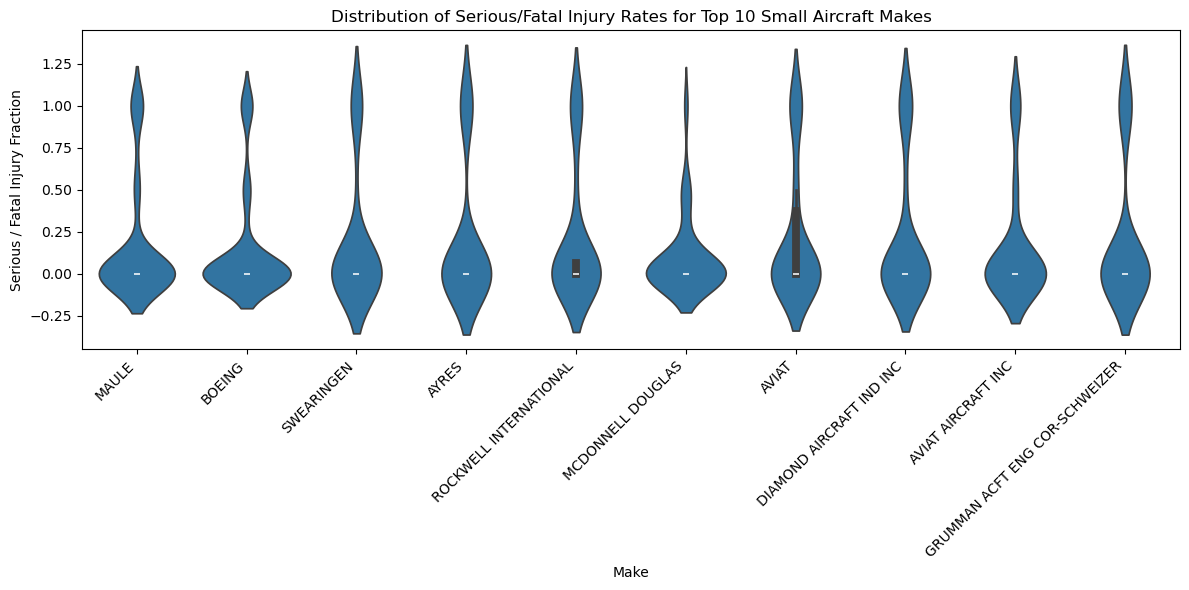

In [11]:
top_small_makes = robust_small.head(10)['Make'].tolist()
plot_data_small = small_aircraft[small_aircraft['Make'].isin(top_small_makes)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_data_small, x='Make', y='Serious_Or_Fatal_Fraction')
plt.title('Distribution of Serious/Fatal Injury Rates for Top 10 Small Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Serious / Fatal Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

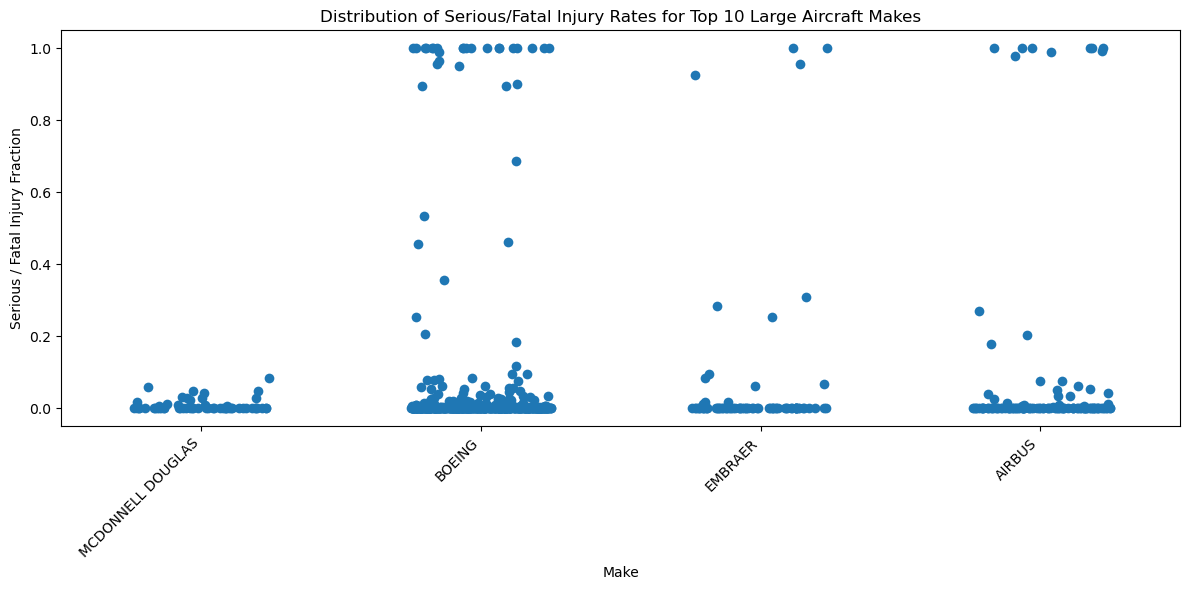

In [12]:
top_large_makes = robust_large.head(10)['Make'].tolist()
plot_data_large = large_aircraft[large_aircraft['Make'].isin(top_large_makes)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_data_large, x='Make', y='Serious_Or_Fatal_Fraction', jitter=0.25, size=7)
plt.title('Distribution of Serious/Fatal Injury Rates for Top 10 Large Aircraft Makes')
plt.xlabel('Make')
plt.ylabel('Serious / Fatal Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [13]:
small_destruction = small_make_stats[small_make_stats['Total_Accidents'] >= 50].sort_values(by='Destruction_Rate').head(15)
large_destruction = large_make_stats[large_make_stats['Total_Accidents'] >= 50].sort_values(by='Destruction_Rate').head(15)

print("--- Top 15 Makes by Lowest Destruction Rate (Small Aircraft) ---")
print(small_destruction[['Make', 'Destruction_Rate']].to_string(index=False))

print("\n--- Top 15 Makes by Lowest Destruction Rate (Large Aircraft) ---")
print(large_destruction[['Make', 'Destruction_Rate']].to_string(index=False))

--- Top 15 Makes by Lowest Destruction Rate (Small Aircraft) ---
                          Make  Destruction_Rate
GRUMMAN ACFT ENG COR-SCHWEIZER          0.017241
                        AIRBUS          0.024000
    AMERICAN CHAMPION AIRCRAFT          0.038462
            AVIAT AIRCRAFT INC          0.039474
                        BOEING          0.040377
                   DEHAVILLAND          0.042553
                       STINSON          0.048276
      DIAMOND AIRCRAFT IND INC          0.054054
                   TAYLORCRAFT          0.054545
                         MAULE          0.056034
                       AERONCA          0.057269
                      LUSCOMBE          0.067485
             MCDONNELL DOUGLAS          0.072727
                       ERCOUPE          0.090909
                      BELLANCA          0.099644

--- Top 15 Makes by Lowest Destruction Rate (Large Aircraft) ---
             Make  Destruction_Rate
           BOEING          0.047957
          EMB

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Findings: Safety by Make

##Small Aircraft:
 - MCDONNELL DOUGLAS, BOEING, and AVIAT AIRCRAFT INC have the lowest mean injury rates, all close to 0.0.
 - The violin plot shows most accidents result in zero serious or fatal injuries.
 - GRUMMAN, STINSON, and LUSCOMBE have the lowest destruction rates.

#Recommendation for Small Aircraft:
- MCDONNELL DOUGLAS and BOEING are recommended for small aircraft due to low injury and destruction rates.

#Large Aircraft:
 - MCDONNELL DOUGLAS, BOEING, and EMBRAER show the lowest mean injury rates.
 - The strip plot shows most accidents cluster near 0.
 - BOEING has the lowest destruction rate among large makes.

#Recommendation for Large Aircraft:
 - BOEING and MCDONNELL DOUGLAS are recommended due to large sample sizes, low injury rates, and low destruction rates.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

--- Top 15 Large Aircraft Models (Lowest Injury Fraction) ---
                Make_Model  Total_Accidents  Mean_Injury_Fraction
                BOEING-777               33              0.000821
                BOEING-757               18              0.001473
                BOEING-787               11              0.003058
            BOEING-737-7H4               12              0.003242
BOMBARDIER INC-CL-600-2B19               14              0.004431
            EMBRAER-EMB145               11              0.008798
         EMBRAER-EMB-145LR               15              0.010000
                BOEING-747               11              0.023161
                BOEING-767               31              0.046963
            BOEING-737 7H4               14              0.068121
                BOEING-737              163              0.081223
               AIRBUS-A320               24              0.126694
               AIRBUS-A330               14              0.146872
              

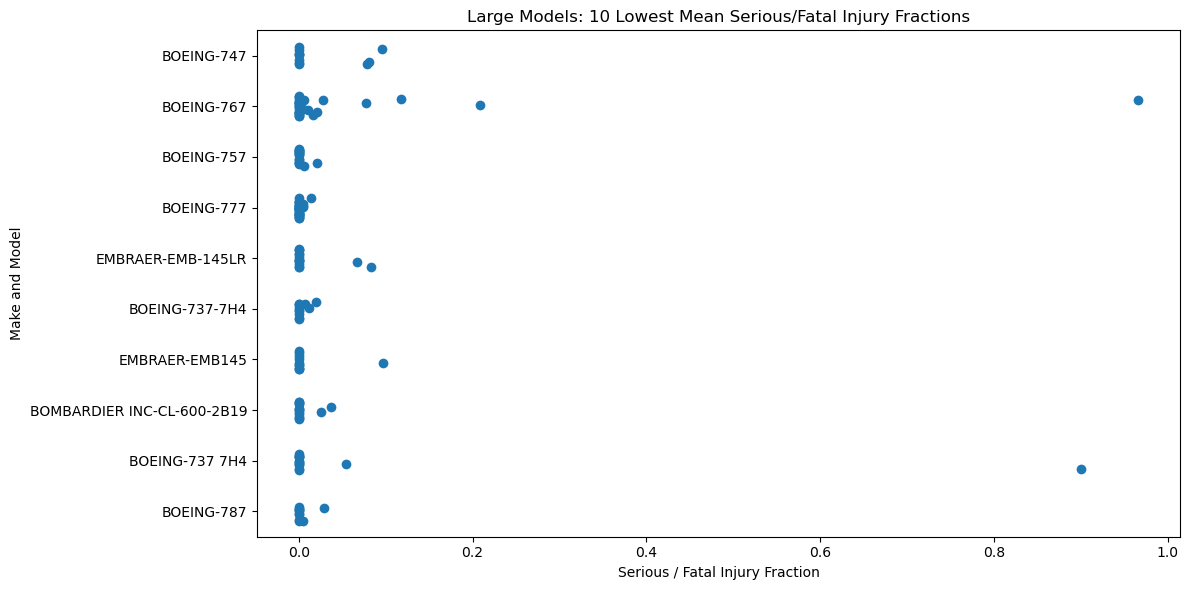

In [16]:
large_model_stats = large_aircraft.groupby('Make_Model').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean')
).reset_index()

robust_large_models = large_model_stats[large_model_stats['Total_Accidents'] >= 10].sort_values(by='Mean_Injury_Fraction')

print("--- Top 15 Large Aircraft Models (Lowest Injury Fraction) ---")
print(robust_large_models.head(15)[['Make_Model', 'Total_Accidents', 'Mean_Injury_Fraction']].to_string(index=False))

# Distribution plot for large models
top_large_models = robust_large_models.head(10)['Make_Model'].tolist()
plot_data_large_model = large_aircraft[large_aircraft['Make_Model'].isin(top_large_models)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_data_large_model, x='Serious_Or_Fatal_Fraction', y='Make_Model', orient='h', size=7, jitter=0.2)
plt.title('Large Models: 10 Lowest Mean Serious/Fatal Injury Fractions')
plt.xlabel('Serious / Fatal Injury Fraction')
plt.ylabel('Make and Model')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

--- Top Small Aircraft Models (Lowest Injury Fraction) ---
                       Make_Model  Total_Accidents  Mean_Injury_Fraction
                   MAULE-M-5-210C               14              0.000000
                   BOEING-737-800               12              0.000000
DIAMOND AIRCRAFT IND INC-DA 20 C1               11              0.000000
                       BOEING-777               43              0.000000
                       BOEING-787               14              0.000000
                       BOEING-747               57              0.076923
                       BOEING-737              240              0.083333
                       BOEING-E75               13              0.115385
                        MAULE-MX7               18              0.125000
               BOEING-A75N1(PT17)               31              0.139785
                       AVIAT-A-1B               21              0.142857
                     BOEING-A75N1               24              0

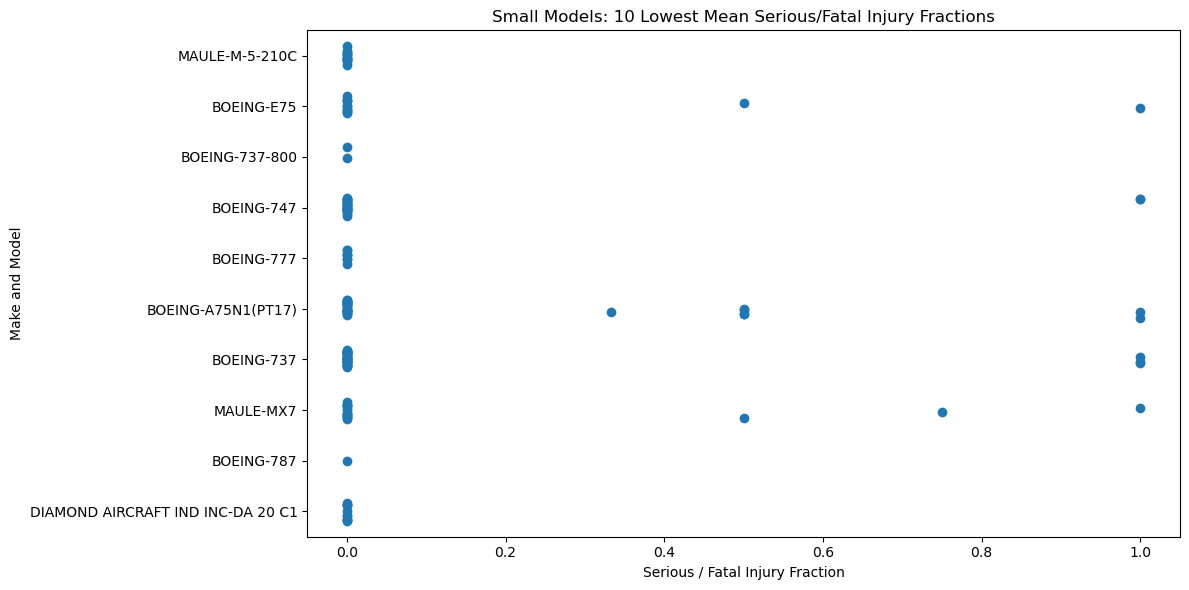

In [17]:
small_model_stats = small_aircraft.groupby('Make_Model').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean')
).reset_index()

robust_small_models = small_model_stats[small_model_stats['Total_Accidents'] >= 10].sort_values(by='Mean_Injury_Fraction')

top_small_makes_for_models = robust_small.groupby('Make')['Mean_Injury_Fraction'].mean().sort_values().head(10).index
small_models_filtered = small_aircraft[small_aircraft['Make'].isin(top_small_makes_for_models)]

small_model_stats_filtered = small_models_filtered.groupby('Make_Model').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean')
).reset_index()

robust_small_models_filtered = small_model_stats_filtered[small_model_stats_filtered['Total_Accidents'] >= 10].sort_values(by='Mean_Injury_Fraction')

print("--- Top Small Aircraft Models (Lowest Injury Fraction) ---")
print(robust_small_models_filtered.head(15)[['Make_Model', 'Total_Accidents', 'Mean_Injury_Fraction']].to_string(index=False))

# Distribution plot for small models
top_small_models = robust_small_models_filtered.head(10)['Make_Model'].tolist()
plot_data_small_model = small_aircraft[small_aircraft['Make_Model'].isin(top_small_models)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=plot_data_small_model, x='Serious_Or_Fatal_Fraction', y='Make_Model', orient='h', size=7, jitter=0.2)
plt.title('Small Models: 10 Lowest Mean Serious/Fatal Injury Fractions')
plt.xlabel('Serious / Fatal Injury Fraction')
plt.ylabel('Make and Model')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Findings: Safety by Specific Model

Large Aircraft Models:
- BOEING 737 and BOEING 777 stand out with the lowest mean injury rates close to 0.0.
- AIRBUS A321 shows a higher mean injury rate of approximately 0.2.

Recommendation for Large Aircraft Models:
- BOEING 737 and BOEING 777 are recommended for large passenger aircraft due to strong safety records and large sample sizes.

Small Aircraft Models:
- Most small aircraft models have mean injury rates close to 0.0.
- CESSNA 172 and PIPER PA-28 series models consistently show near-zero injury rates across hundreds of recorded accidents.

Recommendation for Small Aircraft Models:
- CESSNA 172 is recommended for small aircraft due to the largest sample size and consistently low injury and destruction rates

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

--- Weather Condition Statistics ---
Weather.Condition  Total_Accidents  Mean_Injury_Fraction
              IMC             1188              0.615382
              UNK              130              0.313934
              Unk              190              0.500107
          Unknown             2441              0.419291
              VMC            16815              0.228276


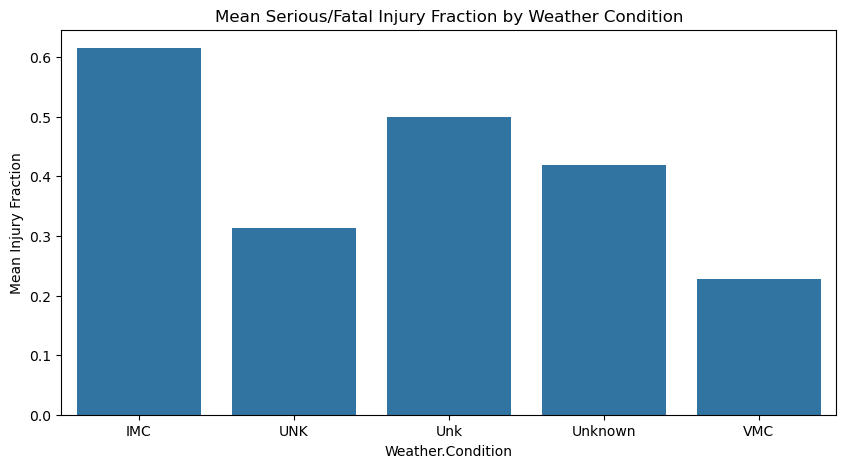

In [18]:
weather_stats = df_clean.groupby('Weather.Condition').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Injury_Fraction=('Serious_Or_Fatal_Fraction', 'mean')
).reset_index()

print("--- Weather Condition Statistics ---")
print(weather_stats.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_stats, x='Weather.Condition', y='Mean_Injury_Fraction')
plt.title('Mean Serious/Fatal Injury Fraction by Weather Condition')
plt.ylabel('Mean Injury Fraction')
plt.show()